___

# <font color= #99C8F5> **Autoencoder for CIFAR-10 Generation** </font>
#### <font color= #2E9AFE> `Deep Learning`</font>
<Strong> Sofía Maldonado, Óscar Josué Rocha & Viviana Toledo </Strong>

_17/02/2026._

___

# <font color= #99C8F5> **Introduction** </font>

Autoencoders are a type of neural network made up of two parts: first, an **encoder** that encodes input data down to a compressed, lower-dimention representation (***latent space***). Then, a **decoder** reconstructs the input back to its original form, in the best way it can. 

This arquitecture makes autoencoders very useful for image generation purposes: if an encoder can learn to represent a type of data (text, images, or anything else) in a small space, that space can be used to generate new samples based on that information, mimiquing what the training data contained. 

In this exercise, we are using the CIFAR-10 dataset [1] to train a full autoencoder network that can generate images in the dataset's 10 classes. These classes are:
- Airplanes
- Cars
- Birds
- Cats
- Deer
- Dogs
- Frogs
- Horses
- Ships
- Trucks

---

In [ ]:
# General
import numpy as np
import pandas as pd
from keras.datasets import cifar10

# Visualization
import matplotlib.pyplot as plt

# Models
import tensorflow as tf
from tensorflow.python.client import device_lib
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, UpSampling2D
from keras.optimizers import Adam
from keras import Model

In [2]:
print(device_lib.list_local_devices())
print(tf.__version__)
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 3273487897614653806
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 3102736384
locality {
  bus_id: 1
  links {
  }
}
incarnation: 1748711303775661479
physical_device_desc: "device: 0, name: NVIDIA GeForce RTX 2060, pci bus id: 0000:09:00.0, compute capability: 7.5"
xla_global_id: 416903419
]
2.20.0
Num GPUs Available:  1


I0000 00:00:1771207732.112606   28184 gpu_device.cc:2020] Created device /device:GPU:0 with 2959 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060, pci bus id: 0000:09:00.0, compute capability: 7.5


# <font color= #99C8F5> **Data Loading & Visualization** </font>

In [3]:
# Load Data
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((50000, 32, 32, 3), (10000, 32, 32, 3), (50000, 1), (10000, 1))

The CIFAR-10 dataset contains 50K training images and 10K testing images. These images have a size of 32x32 pixels with an RGB channel.

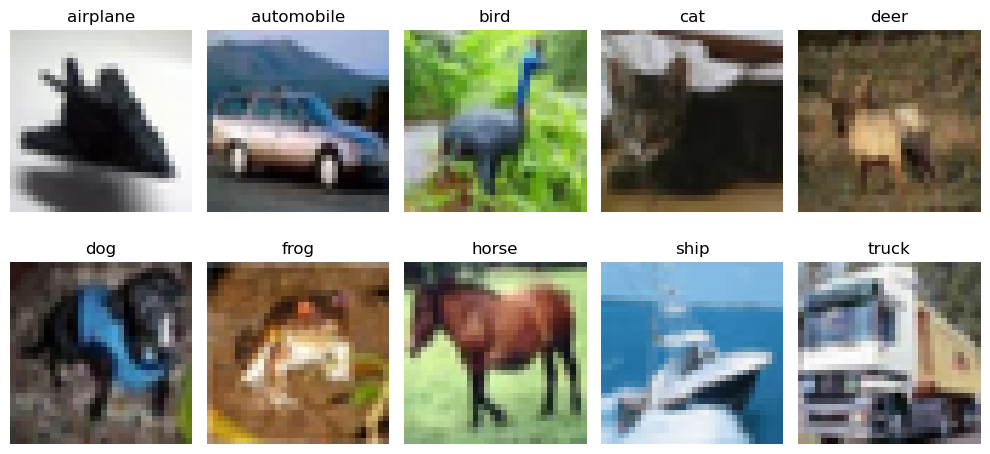

In [4]:
# Flatten labels for visualization
y_train = y_train.flatten()

# Class names
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Create the plot
plt.figure(figsize=(10, 5))
# Select an image for each class
for class_id in range(10):
    index = np.where(y_train == class_id)[0][0]
    # Plot the imaage
    plt.subplot(2, 5, class_id + 1)
    plt.imshow(X_train[index])
    plt.title(class_names[class_id])
    plt.axis('off')

plt.tight_layout()
plt.show()

The images have a low resolution, which makes them highly pixelated. This should be taken into account when evaluating the results of the autoencoder.

# <font color= #99C8F5> **Preprocessing** </font>

The objective of this activity is to build an autoencoder capable of recreating images of the CIFAR-10 dataset. For this reason, data-augmentation techniques would be ill-advised, since the learning and comparison between images would be hindered. Thus, only a normalization will be applied.

In [5]:
# Normalization
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255

In [6]:
X_train.shape, X_test.shape

((50000, 32, 32, 3), (10000, 32, 32, 3))

In [7]:
X_train.min(), X_train.max()

(np.float32(0.0), np.float32(1.0))

# <font color= #99C8F5> **Modeling** </font>

The model architecture will mimic a Convolutional Autoencoder with three levels of compression:

$$
1024_{input}  \rightarrow 256_{h_1} \rightarrow 128_{h_2} \rightarrow 64_{h_3} \rightarrow 32_z \leftarrow 64_{h_3} \leftarrow 128_{h_2} \leftarrow 256_{h_1} \leftarrow 1024_{output}
$$

The construction of the neural network using Keras was made based on articles [2] and [3] (check references below)

In [8]:
num_labels = 10
input_shape = (32,32,3) #1024

In [9]:
model = Sequential(name='Convolutional_AE')

# Encoder
model.add(Conv2D(32, input_shape=input_shape ,kernel_size=3, activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(32, kernel_size=3, activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(1,2)))

model.add(Conv2D(32, kernel_size=3, activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2,1)))

model.add(Conv2D(32, kernel_size=3, activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(1,2)))

# Decoder
model.add(Conv2D(32, kernel_size=3, activation='relu', padding='same'))
model.add(UpSampling2D(size=(1,2)))

model.add(Conv2D(32, kernel_size=3, activation='relu', padding='same'))
model.add(UpSampling2D(size=(2,1)))

model.add(Conv2D(32, kernel_size=3, activation='relu', padding='same'))
model.add(UpSampling2D(size=(1,2)))

model.add(Conv2D(32, kernel_size=3, activation='relu', padding='same'))
model.add(UpSampling2D(size=(2,2)))

model.add(Conv2D(3, kernel_size=3, activation='sigmoid', padding='same'))

model.summary()

/home/sofi/miniconda3/envs/mnlpp/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1771207733.983060   28184 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2959 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060, pci bus id: 0000:09:00.0, compute capability: 7.5


Model: "Convolutional_AE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 8, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 8, 32)      │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 4, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 16, 8, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 8, 32)      │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,499 (259.76 KB)

 Trainable params: 66,499 (259.76 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
optimizer = Adam(learning_rate=1e-5)

In [11]:
model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy'
)

In [12]:
model.fit(X_train, X_train, batch_size=256, epochs=50, validation_data=(X_test, X_test))

Epoch 1/50


2026-02-15 20:08:57.465474: I external/local_xla/xla/service/service.cc:163] XLA service 0x17b09340 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-15 20:08:57.465492: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 2060, Compute Capability 7.5
2026-02-15 20:08:57.522710: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-15 20:08:57.783382: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91700
2026-02-15 20:08:57.969844: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[256,32,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[256,3,32,32]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_targe

  9/196 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.6931

I0000 00:00:1771207740.461289   28269 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


193/196 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.6926

2026-02-15 20:09:03.880913: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[80,32,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[80,3,32,32]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-02-15 20:09:03.905419: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[80,32,16,16]{3,2,1,0}, u8[0]{0}) custom-call(f32[80,32,16,16]{3,2,1,0}, f32[32,32,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cud

196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.6926

2026-02-15 20:09:06.267361: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[256,32,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[256,3,32,32]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-02-15 20:09:06.344427: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[256,32,16,16]{3,2,1,0}, u8[0]{0}) custom-call(f32[256,32,16,16]{3,2,1,0}, f32[32,32,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="_

196/196 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - loss: 0.6917 - val_loss: 0.6887
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.6725 - val_loss: 0.6478
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.6342 - val_loss: 0.6260
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.6202 - val_loss: 0.6164
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.6129 - val_loss: 0.6110
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.6081 - val_loss: 0.6068
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.6044 - val_loss: 0.6036
Epoch 8/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.6014 - val_loss: 0.6007
Epoch 9/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.5988 - val_loss: 0.5983
Epoch 10/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.5965 - val_loss: 0.5962
Epoch 11/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.5946 - val_loss: 0.5945
Epoch 12/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/st

In [13]:
preds = model.predict(X_test)

2026-02-15 20:11:54.198206: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,32,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,3,32,32]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-02-15 20:11:54.211603: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,32,16,16]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,32,16,16]{3,2,1,0}, f32[32,32,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cud

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [14]:
preds.min(), preds.max()

(np.float32(0.003154987), np.float32(0.99733835))

Helper function for displaying an example image and how the full Autoencoder reconstructs it.

In [15]:
def display(array1, array2):
    """Displays ten random images from each array."""
    n = 10
    indices = np.random.randint(len(array1), size=n)
    images1 = array1[indices, :]
    images2 = array2[indices, :]

    plt.figure(figsize=(20, 4))
    for i, (image1, image2) in enumerate(zip(images1, images2)):
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(image1.reshape(32, 32, 3))
        plt.gray()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(image2.reshape(32, 32, 3))
        plt.gray()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    plt.show()


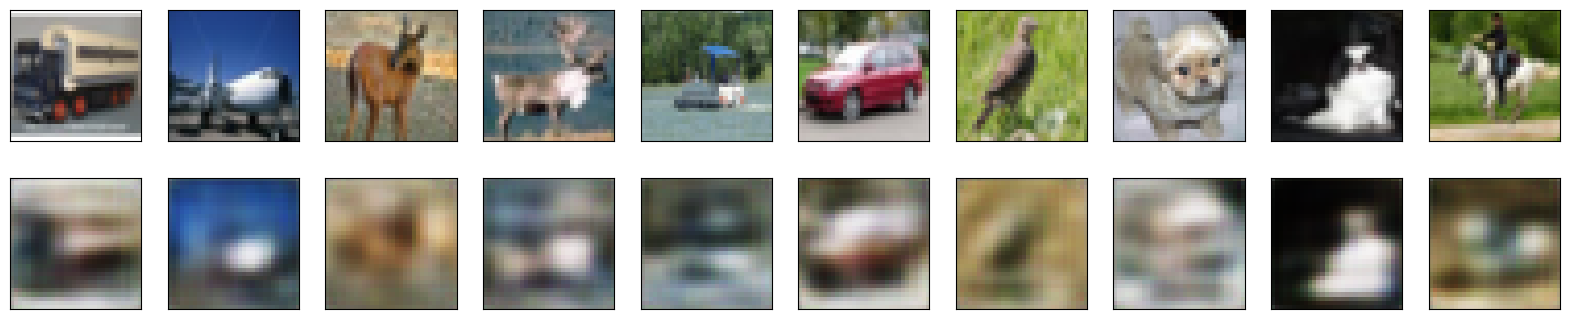

In [16]:
display(X_test, preds)

# <font color= #99C8F5> **Conclusions** </font>

A compact model was proposed as a starting point for the dataset. With 50 epochs to make up for the number of parameters, the images are a little blurry, with only the overall figure being detected in each case. 

# <font color= #99C8F5> **Bibliography and References** </font>

[1] Krizhevsky, A. (2009). Learning Multiple Layers of Features from Tiny Images. **University of Toronto**. https://www.cs.toronto.edu/~kriz/learning-features-2009-TR.pdf

[2] Valdarrama, S. (2021) Convolutional autoencoder for image denoising. **Keras**. https://keras.io/examples/vision/autoencoder/

[3] Chollet, F. (2016) Building Autoencoders in Keras. **The Keras Blog**. https://blog.keras.io/building-autoencoders-in-keras.html 